In [1]:
!pip install pyro-ppl
!pip install yfinance
!pip install scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 9.8 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/JanParlesak/BNN_forecasting
!git pull https://github.com/JanParlesak/BNN_forecasting



%cd 'BNN_forecasting'

Cloning into 'BNN_forecasting'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (230/230), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 245 (delta 105), reused 117 (delta 40), pack-reused 15 (from 1)
Receiving objects: 100% (245/245), 6.56 MiB | 13.36 MiB/s, done.
Resolving deltas: 100% (107/107), done.
fatal: not a git repository (or any of the parent directories): .git
/content/BNN_forecasting


In [3]:
from functions import *
from models import *
from data_processing import *

In [4]:
import seaborn as sns

In [5]:
df = yf.download('^SPGSCI', start="2010-09-23", end="2019-01-10", interval='1mo')
df.reset_index(inplace=True)
df.head()

/tmp/ipykernel_3273/3500886638.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('^SPGSCI', start="2010-09-23", end="2019-01-10", interval='1mo')
[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,^SPGSCI,^SPGSCI,^SPGSCI,^SPGSCI,^SPGSCI
0,2010-10-01,564.159973,577.950012,544.909973,547.390015,0
1,2010-11-01,575.840027,610.169983,543.929993,567.359985,0
2,2010-12-01,631.830017,633.770020,575.419983,577.049988,0
3,2011-01-01,655.260010,657.619995,611.809998,635.109985,0
4,2011-02-01,690.849976,709.159973,639.979980,654.390015,0


## Get Data

In [6]:
train_data, test_data = download_finance_data(ticker = '^SPGSCI', start="2010-09-23", end="2019-01-10", interval='1mo')

/content/BNN_forecasting/data_processing.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start= start, end = end, interval= interval)
[*********************100%***********************]  1 of 1 completed


In [7]:
train_x_one, train_y_one = split_sequences(train_data, 3)
test_x_one, test_y_one = split_sequences(test_data,3)

x_train_one = torch.tensor(train_x_one.reshape(train_x_one.shape[0],train_x_one.shape[1],1)).float()
y_train_one = torch.tensor(train_y_one.reshape(train_y_one.shape[0],1,1)).float()
x_test_one = torch.tensor(test_x_one.reshape(test_x_one.shape[0],test_x_one.shape[1],1)).float()
y_test_one = torch.tensor(test_y_one.reshape(test_y_one.shape[0],1,1)).float()

In [8]:
train_data_one = myDataset(x_train_one, y_train_one)
test_data_one = myDataset(x_test_one, y_test_one)
train_loader_one = torch.utils.data.DataLoader(train_data_one, batch_size=32, shuffle=False)
test_loader_one = torch.utils.data.DataLoader(test_data_one ,batch_size=1,shuffle=False)

In [9]:
train_x_multi ,train_y_multi = multi_time(train_data, 3, 3)
test_x_multi, test_y_multi = multi_time(test_data, 3, 3)

In [10]:
y_test_multi = test_y_multi[::3]
x_test_multi = test_x_multi[::3]
x_train_multi = train_x_multi[::3]
y_train_multi = train_y_multi[::3]

In [11]:
x_train_multi = torch.tensor(x_train_multi.reshape(x_train_multi.shape[0],x_train_multi.shape[1],1)).float()
y_train_multi = torch.tensor(y_train_multi.reshape(y_train_multi.shape[0],y_train_multi.shape[1],1)).float()
x_test_multi = torch.tensor(x_test_multi.reshape(x_test_multi.shape[0],x_test_multi.shape[1],1)).float()
y_test_multi = torch.tensor(y_test_multi.reshape(y_test_multi.shape[0],y_train_multi.shape[1],1)).float()

In [12]:
train_data_multi = myDataset(x_train_multi,y_train_multi)
test_data_multi = myDataset(x_test_multi,y_test_multi)
train_loader_multi = torch.utils.data.DataLoader(train_data_multi, batch_size=32, shuffle=False)
test_loader_multi = torch.utils.data.DataLoader(test_data_multi, batch_size=1, shuffle=False)

## BNN Onestep CNN

  0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


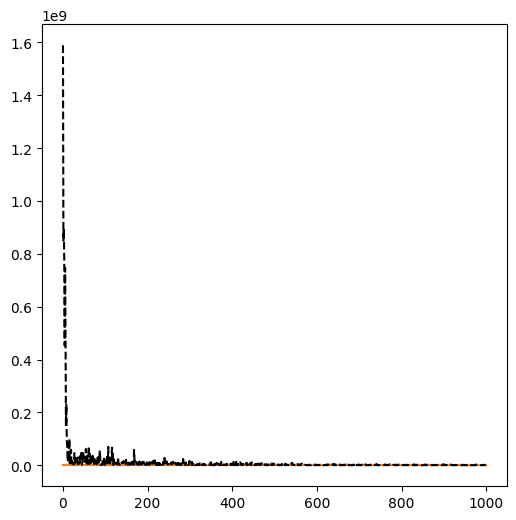

In [13]:
model_cnn_one = BNN_onestep_cnn()
guide_model_cnn_one = AutoDiagonalNormal(model_cnn_one)

fit_svi(model_cnn_one, guide_model_cnn_one, train_loader_one, lr=0.01, model_name = "cnn_one", num_epochs= 1000)

In [14]:
saved_cnn_one= torch.load("cnn_one.pt", weights_only=False)
model_cnn_one.load_state_dict(saved_cnn_one['model'])
guide_cnn_one = saved_cnn_one['guide']
#pyro.get_param_store().load("cnn_one_params.pt")

In [15]:
pred_cnn_one, plus_error_cnn_one, minus_error_cnn_one, covariance_cnn_one,_ = predict(model_cnn_one, guide_cnn_one, test_loader_one)

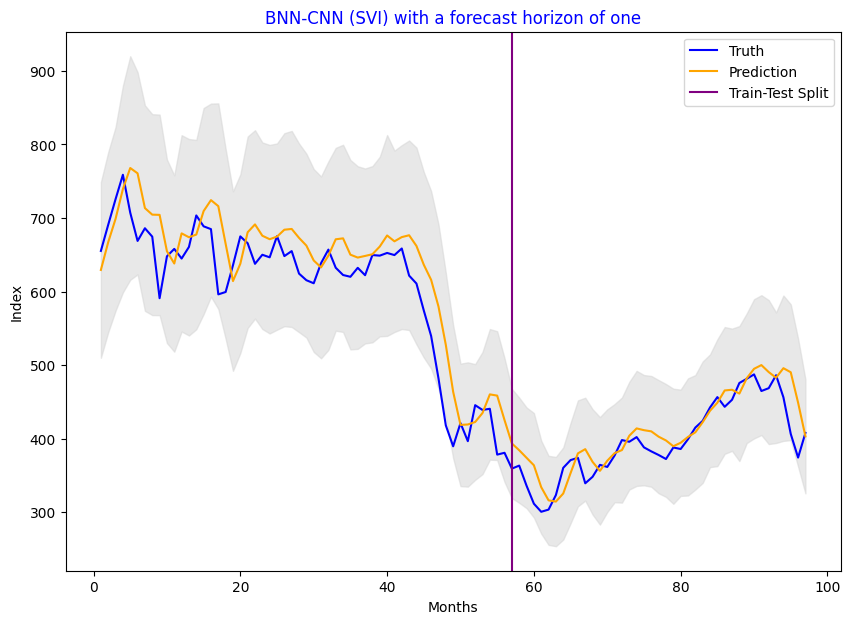

In [16]:
plot_results(3, test_y_one, pred_cnn_one, np.vstack(plus_error_cnn_one).squeeze().tolist(),
             np.vstack(minus_error_cnn_one).squeeze().tolist(), title = 'BNN-CNN (SVI) with a forecast horizon of one', x_train = x_train_one)

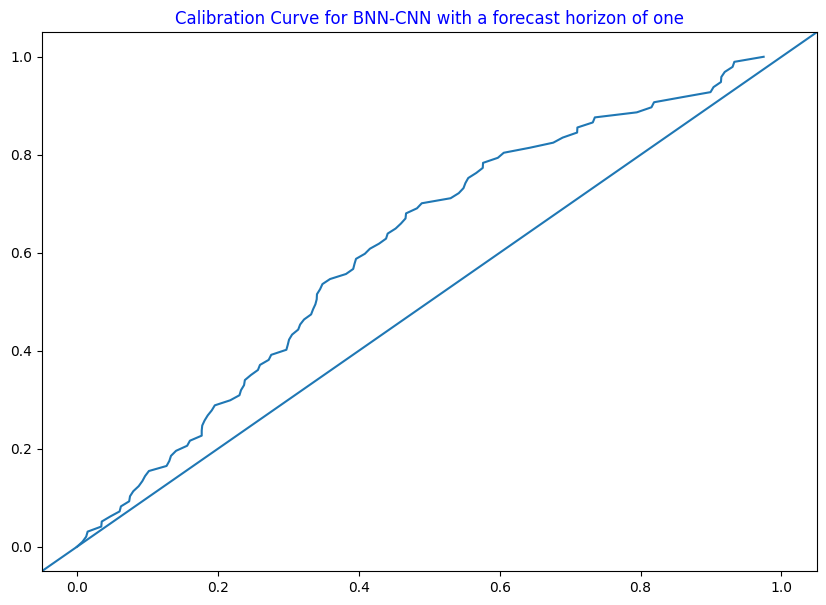

In [17]:
auc_curve(pred_cnn_one, test_y_one, covariance_cnn_one, 'Calibration Curve for BNN-CNN with a forecast horizon of one')

In [18]:
distance(pred_cnn_one, test_y_one, covariance_cnn_one)

(np.float64(0.13), 1)

In [19]:
print(rmse(test_y_one.flatten(),np.concatenate(pred_cnn_one, axis =0)))
print(mape(test_y_one.flatten(),np.concatenate(pred_cnn_one, axis =0)))
print(mae(test_y_one.flatten(),np.concatenate(pred_cnn_one, axis =0)))

40.203
0.061
30.277


## BNN Multistep CNN

  0%|          | 0/1000 [00:00<?, ?it/s]

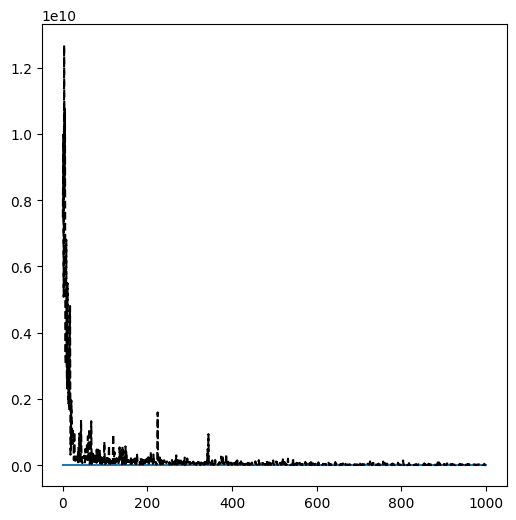

In [20]:
model_cnn_multi = BNN_multistep_cnn()
mean_field_guide_cnn_multi = AutoDiagonalNormal(model_cnn_multi)
fit_svi(model_cnn_multi, mean_field_guide_cnn_multi, train_loader_multi, 'cnn_multi', lr=0.01, num_epochs=1000,  plot=True)

In [21]:
saved_cnn_multi = torch.load('cnn_multi.pt', weights_only=False)
model_cnn_multi.load_state_dict(saved_cnn_multi['model'])
guide_cnn_multi = saved_cnn_multi['guide']
#pyro.get_param_store().load("cnn_multi_params.pt")

In [22]:
pred_cnn_multi, plus_error_cnn_multi, minus_error_cnn_multi, covariance_cnn_multi, real_cnn_multi = predict(model_cnn_multi, guide_cnn_multi, test_loader_multi, num_samples = 50)

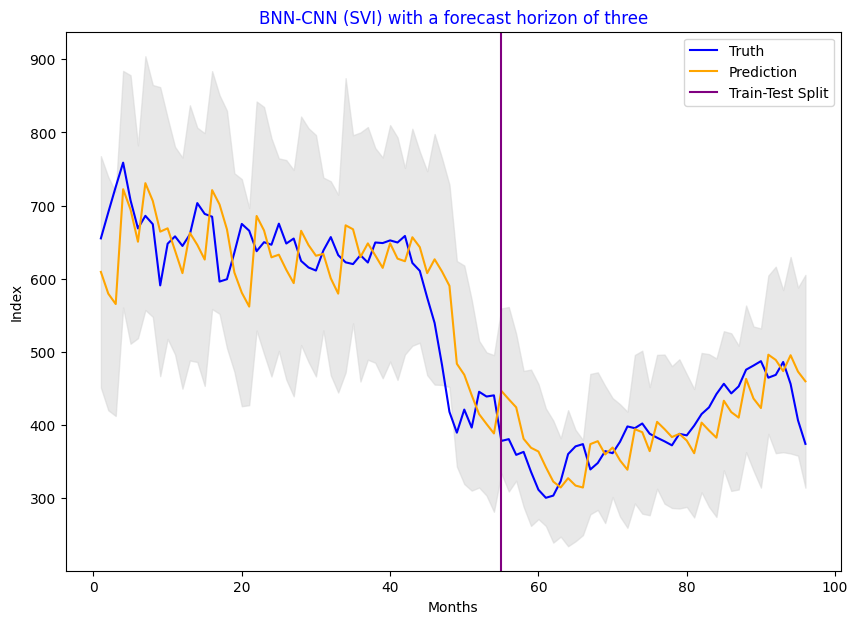

In [23]:
plot_results(3, np.concatenate(torch.cat(real_cnn_multi).numpy()), np.concatenate(pred_cnn_multi), np.concatenate(plus_error_cnn_multi), np.concatenate(minus_error_cnn_multi), 'BNN-CNN (SVI) with a forecast horizon of three', train_x_multi)

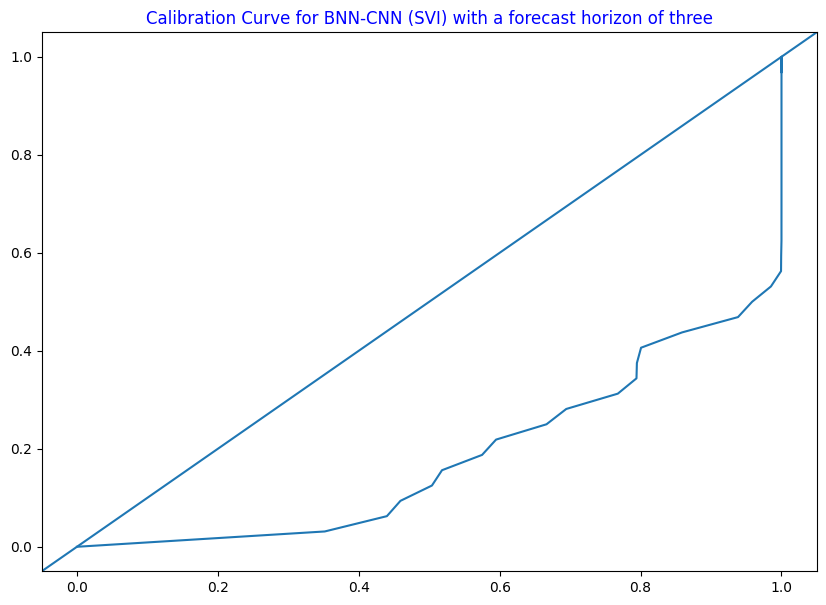

In [24]:
auc_curve(pred_cnn_multi, np.concatenate(torch.cat(real_cnn_multi).numpy()), covariance_cnn_multi, 'Calibration Curve for BNN-CNN (SVI) with a forecast horizon of three')

In [25]:
cnn_multi_auc_curve = return_auc_curve(pred_cnn_multi, np.concatenate(torch.cat(real_cnn_multi).numpy()), covariance_cnn_multi)

In [26]:
distance(pred_cnn_multi, np.concatenate(torch.cat(real_cnn_multi).numpy()), covariance_cnn_multi)

(np.float64(0.354), 0)

In [27]:
print(rmse(np.concatenate(torch.cat(real_cnn_multi).numpy()).squeeze(),np.concatenate(pred_cnn_multi)))
print(mape(np.concatenate(torch.cat(real_cnn_multi).numpy()).squeeze(),np.concatenate(pred_cnn_multi)))
print(mae(np.concatenate(torch.cat(real_cnn_multi).numpy()).squeeze(),np.concatenate(pred_cnn_multi)))

52.387
0.084
41.656


## One-Step Linear

  0%|          | 0/1000 [00:00<?, ?it/s]

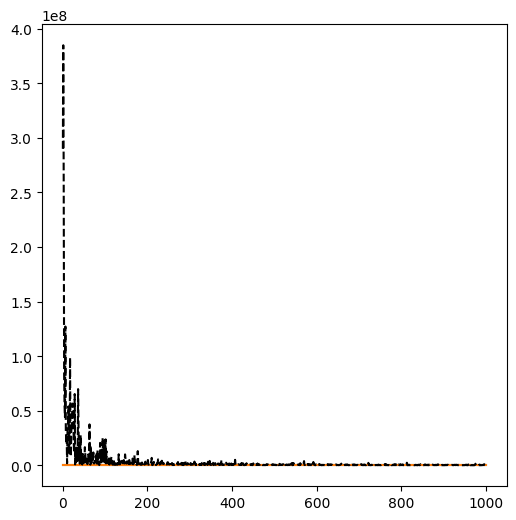

In [28]:
model_linear_one = BNN_linear_onestep()
mean_field_guide_linear_one = AutoDiagonalNormal(model_linear_one)

fit_svi(model_linear_one, mean_field_guide_linear_one, train_loader_one, lr = 0.01, model_name = "linear_one", num_epochs= 1000)

In [29]:
saved_linear_one = torch.load("linear_one.pt", weights_only=False)
model_linear_one.load_state_dict(saved_linear_one['model'])
guide_linear_one = saved_linear_one['guide']
#pyro.get_param_store().load("linear_one_params.pt")

In [30]:
pred_linear_one, plus_error_linear_one, minus_error_linear_one, covariance_linear_one ,_ = predict(model_linear_one, guide_linear_one, test_loader_one)

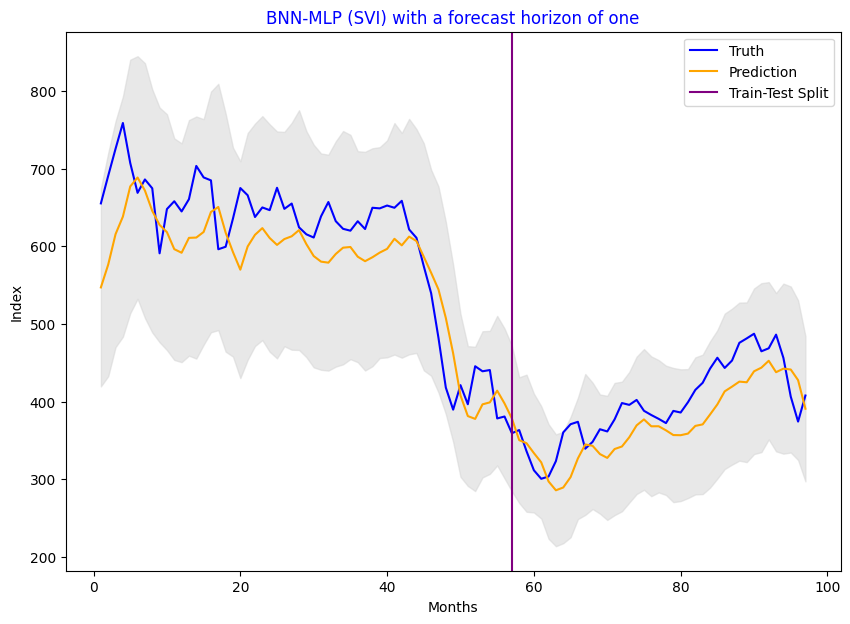

In [31]:
plot_results(3, test_y_one, pred_linear_one, np.vstack(plus_error_linear_one).squeeze().tolist(),
             np.vstack(minus_error_linear_one).squeeze().tolist(), 'BNN-MLP (SVI) with a forecast horizon of one', x_train_one)

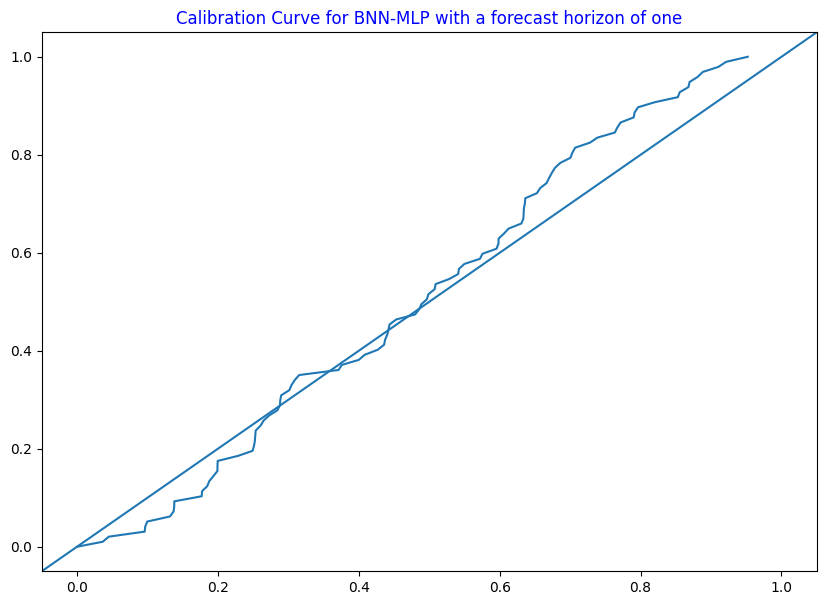

In [33]:
auc_curve(pred_linear_one,test_y_one,covariance_linear_one, 'Calibration Curve for BNN-MLP with a forecast horizon of one')

In [34]:
linear_one_auc_curve = return_auc_curve(pred_linear_one,test_y_one,covariance_linear_one)

In [35]:
distance(pred_linear_one,test_y_one,covariance_linear_one)

(np.float64(0.055), 0)

In [36]:
print(rmse(test_y_one.flatten(),np.concatenate(pred_linear_one, axis =0)))
print(mape(test_y_one.flatten(),np.concatenate(pred_linear_one, axis =0)))
print(mae(test_y_one.flatten(),np.concatenate(pred_linear_one, axis =0)))

48.763
0.08
41.135


## Multi-Step Linear

  0%|          | 0/1000 [00:00<?, ?it/s]

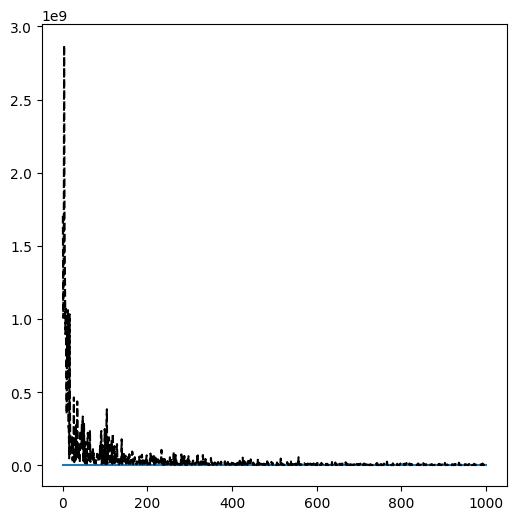

In [37]:
model_linear_multi= BNN_linear_multistep()
mean_field_guide_linear_multi = AutoDiagonalNormal(model_linear_multi)
fit_svi(model_linear_multi, mean_field_guide_linear_multi, train_loader_multi, 'linear_multi', num_epochs = 1000)

In [38]:
saved_model_linear_multi = torch.load("linear_multi.pt", weights_only= False)
guide_linear_multi = saved_model_linear_multi['guide']
model_linear_multi.load_state_dict(saved_model_linear_multi['model'])
#pyro.get_param_store().load("linear_multi_params.pt")

<All keys matched successfully>

In [39]:
pred_linear_multi, plus_error_linear_multi, minus_error_linear_multi, covariance_linear_multi, real_linear_multi  = predict(model_linear_multi, guide_linear_multi, test_loader_multi)


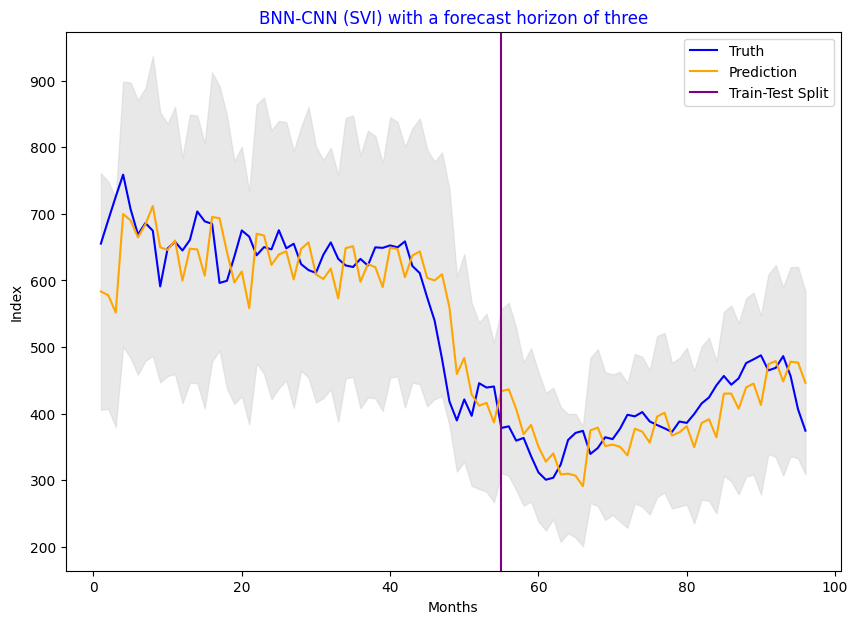

In [40]:
plot_results(3, np.concatenate(torch.cat(real_linear_multi).numpy()), np.concatenate(pred_linear_multi), np.concatenate(plus_error_linear_multi), np.concatenate(minus_error_linear_multi), 'BNN-CNN (SVI) with a forecast horizon of three',train_x_multi)

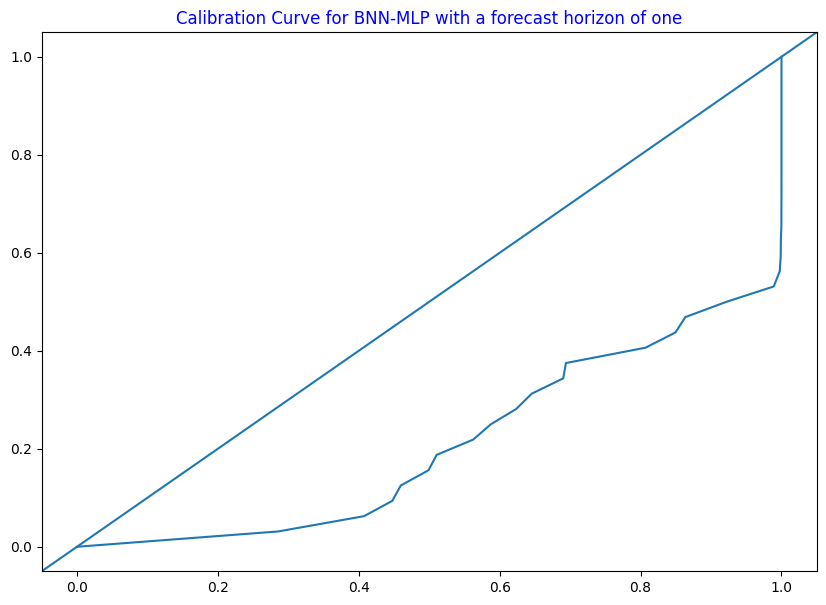

In [41]:
auc_curve(pred_linear_multi, np.concatenate(torch.cat(real_linear_multi).numpy()), covariance_linear_multi,'Calibration Curve for BNN-MLP with a forecast horizon of one')

In [42]:
linear_multi_auc_curve = return_auc_curve(pred_linear_multi, np.concatenate(torch.cat(real_linear_multi).numpy()), covariance_linear_multi)

In [43]:
distance(pred_linear_multi, np.concatenate(torch.cat(real_linear_multi).numpy()), covariance_linear_multi)

(np.float64(0.32), 0)

In [44]:
print(rmse(np.concatenate(torch.cat(real_linear_multi).numpy()).squeeze(),np.concatenate(pred_linear_multi)))
print(mape(np.concatenate(torch.cat(real_linear_multi).numpy()).squeeze(),np.concatenate(pred_linear_multi)))
print(mae(np.concatenate(torch.cat(real_linear_multi).numpy()).squeeze(),np.concatenate(pred_linear_multi)))

51.073
0.082
40.388


# MCMC One-Step


In [46]:
pyro.clear_param_store()
model_mcmc_one = BNN_linear_onestep()
preds_mcmc_one, plus_error_mcmc_one, minus_error_mcmc_one, covariance_mcmc_one = predict_mcmc(model_mcmc_one, x_train_one, y_train_one, x_test_one, num_samples= 50)

Sample: 100%|██████████| 100/100 [07:48,  4.68s/it, step size=6.96e-04, acc. prob=0.906]


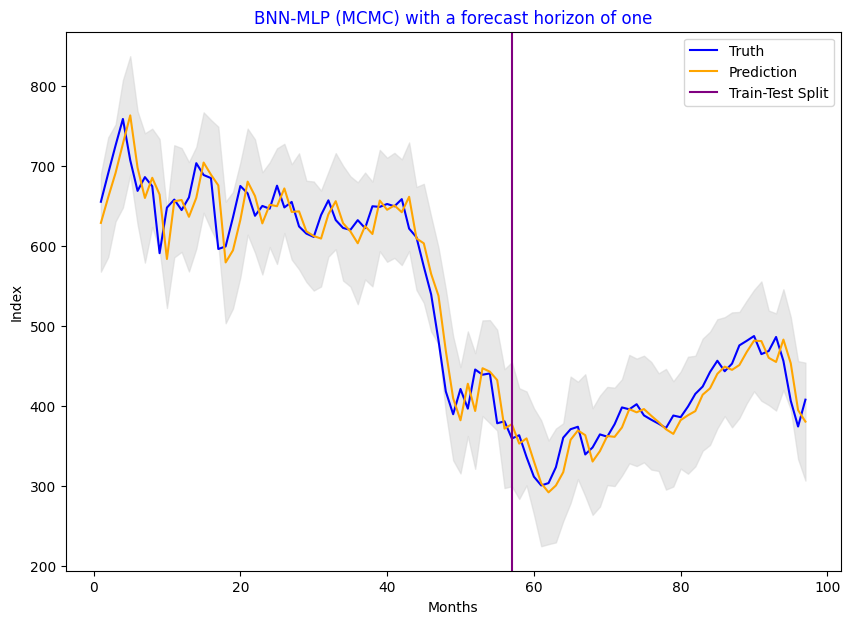

In [47]:
plot_results(3, test_y_one, preds_mcmc_one, plus_error_mcmc_one, minus_error_mcmc_one, title = 'BNN-MLP (MCMC) with a forecast horizon of one', x_train = x_train_one)

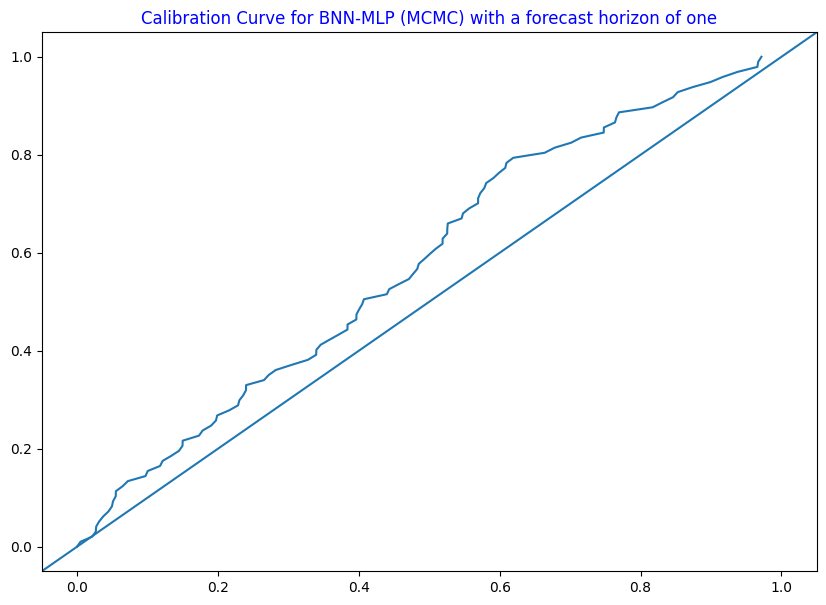

In [48]:
auc_curve(preds_mcmc_one, y_test_one, covariance_mcmc_one, 'Calibration Curve for BNN-MLP (MCMC) with a forecast horizon of one')

In [49]:
preds_mcmc_one.detach().numpy().shape

(97, 1)

In [50]:
distance(preds_mcmc_one.detach().numpy(), y_test_one.flatten().numpy(), covariance_mcmc_one)

(np.float64(0.09), 1)

In [51]:
print(rmse(test_y_one.flatten(),np.concatenate(preds_mcmc_one.detach().numpy(), axis = 0)))
print(mape(test_y_one.flatten(),np.concatenate(preds_mcmc_one.detach().numpy(), axis = 0)))
print(mae(test_y_one.flatten(),np.concatenate(preds_mcmc_one.detach().numpy(), axis = 0)))

26.956
0.042
21.167


## MCMC Multi-Step

In [52]:
model_mcmc_multi = BNN_linear_multistep()
preds_mcmc_multi, plus_error_mcmc_multi, minus_error_mcmc_multi, covariance_mcmc_multi = predict_mcmc(model_mcmc_multi, x_train_multi, y_train_multi, x_test_multi, num_samples= 50)

Sample: 100%|██████████| 100/100 [08:58,  5.38s/it, step size=1.06e-03, acc. prob=0.939]


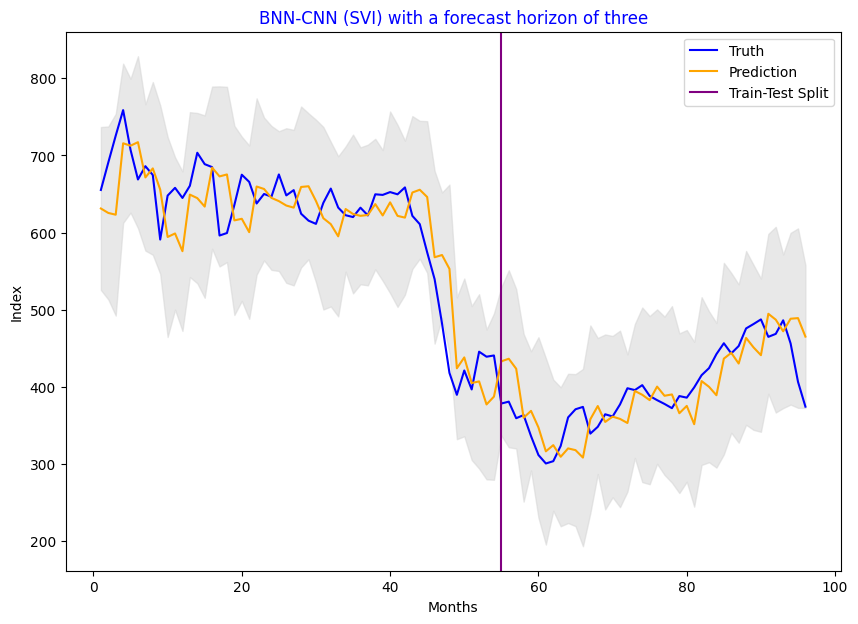

In [53]:
plot_results(3, y_test_multi.flatten(), preds_mcmc_multi.flatten(), plus_error_mcmc_multi, minus_error_mcmc_multi, 'BNN-CNN (SVI) with a forecast horizon of three',train_x_multi)

/content/BNN_forecasting/functions.py:198: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  nssr = [(prediction[i] - test_y[i]) @  (np.linalg.inv(covariance_matrix[i])) @ (prediction[i] - test_y[i]).T for i in range(len(prediction))]


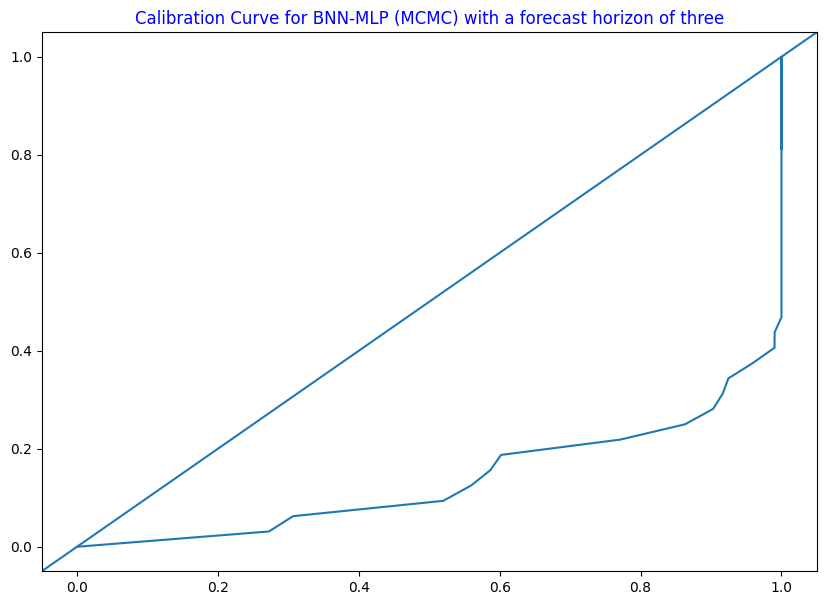

In [54]:
auc_curve(preds_mcmc_multi, np.concatenate(torch.cat(real_linear_multi).numpy()), covariance_mcmc_multi, 'Calibration Curve for BNN-MLP (MCMC) with a forecast horizon of three')